# Лабораторная работа №2
## Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Цель лабораторной работы:** изучение способов предварительной обработки данных для дальнейшего формирования моделей.

В данной части лабораторной работы рассматривается набор данных **Adult**.
Основное внимание уделяется:
- обработке пропусков в категориальных признаках;
- кодированию категориальных признаков.

## Описание набора данных

Набор данных **Adult** содержит информацию о людях и используется для задачи прогнозирования уровня дохода.

В датасете присутствуют категориальные признаки, например:
- `workclass`;
- `education`;
- `marital_status`;
- `occupation`;
- `relationship`;
- `race`;
- `sex`;
- `native_country`;
- `income`.

В данных присутствуют пропуски, обозначенные специальным символом `?`.

Для данной части лабораторной работы рассматриваются только категориальные признаки.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## Загрузка данных

In [26]:
columns_adult = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df_adult = pd.read_csv(
    "../data/raw/adult.csv",
    header=None,
    names=columns_adult,
    na_values=["?", " ?", " ? "],
    skipinitialspace=True
)

df_adult.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Выделение категориальных признаков

Для дальнейшего анализа оставим только категориальные признаки.

In [27]:
categorical_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country",
    "income"
]

df_cat = df_adult[categorical_cols].copy()
df_cat.head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


## Первичный анализ категориальных данных

In [28]:
df_cat.shape

(32561, 9)

In [29]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   workclass       30725 non-null  object
 1   education       32561 non-null  object
 2   marital_status  32561 non-null  object
 3   occupation      30718 non-null  object
 4   relationship    32561 non-null  object
 5   race            32561 non-null  object
 6   sex             32561 non-null  object
 7   native_country  31978 non-null  object
 8   income          32561 non-null  object
dtypes: object(9)
memory usage: 2.2+ MB


In [30]:
df_cat.isna().sum()

workclass         1836
education            0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
native_country     583
income               0
dtype: int64

## Визуализация пропусков

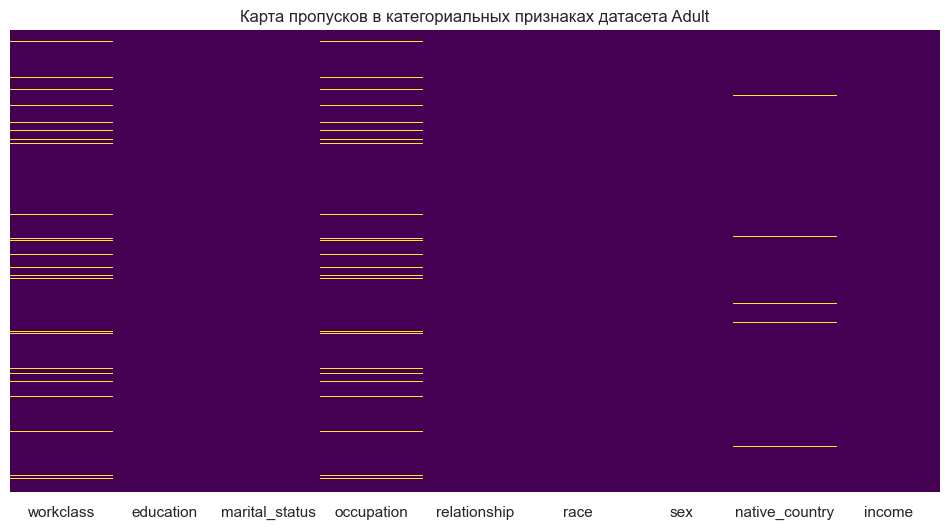

In [31]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cat.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Карта пропусков в категориальных признаках датасета Adult")
plt.show()

## Количество пропусков по признакам

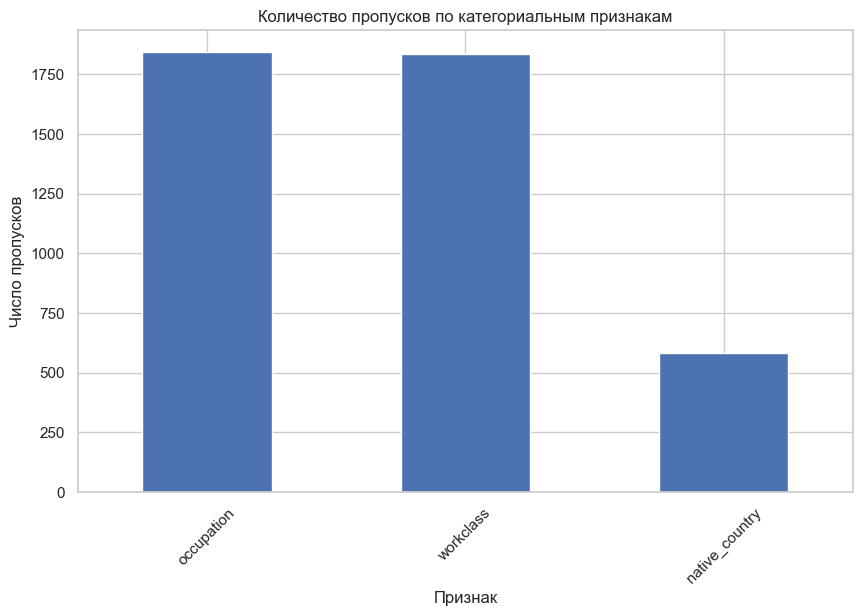

In [33]:
missing_counts = df_cat.isna().sum().sort_values(ascending=False)
missing_counts
missing_counts[missing_counts > 0].plot(kind="bar")
plt.title("Количество пропусков по категориальным признакам")
plt.xlabel("Признак")
plt.ylabel("Число пропусков")
plt.xticks(rotation=45)
plt.show()

## Обработка пропусков

### Заполнение наиболее распространенным значением категории

Для категориальных признаков.

**Допущение:** пропуски распределены случайным образом.
Заполнение пропусков наиболее распространенным значением категории в наименьшей степени повлияет на исходное распределение.

In [34]:
df_cat_imputed = df_cat.copy()

for col in df_cat_imputed.columns:
    most_frequent_value = df_cat_imputed[col].mode()[0]
    df_cat_imputed[col] = df_cat_imputed[col].fillna(most_frequent_value)

df_cat_imputed.head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [35]:
df_cat_imputed.isna().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

## Сравнение распределения категорий до и после заполнения пропусков

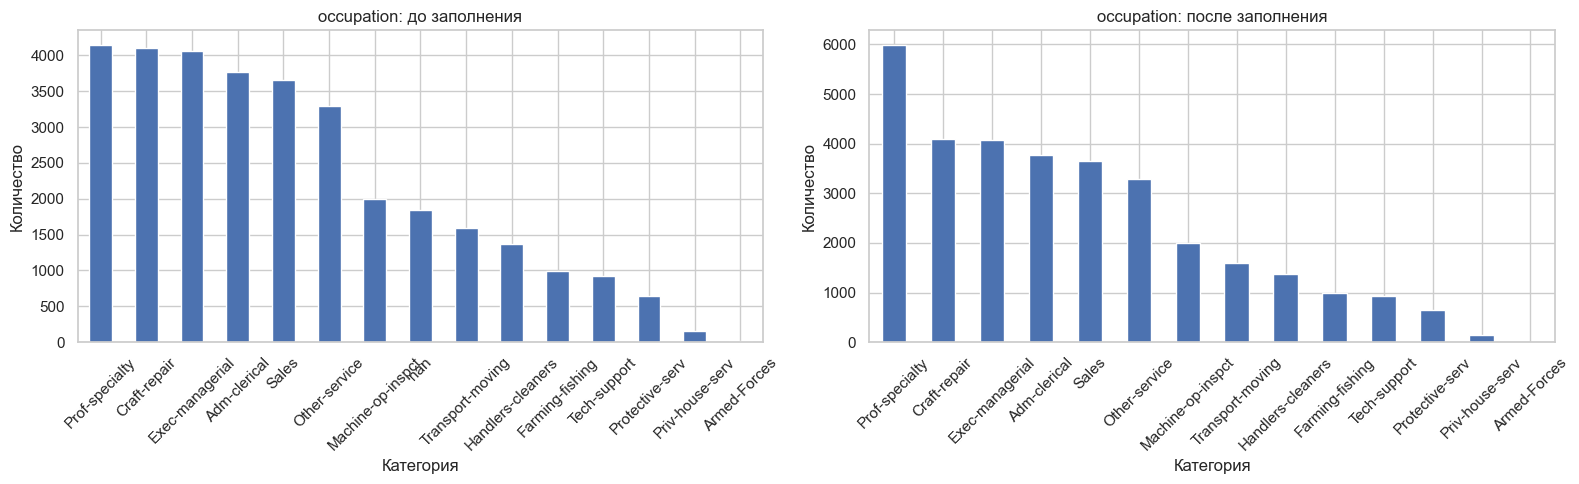

In [36]:
col_to_plot = "occupation"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_cat[col_to_plot].value_counts(dropna=False).plot(kind="bar", ax=axes[0])
axes[0].set_title(f"{col_to_plot}: до заполнения")
axes[0].set_xlabel("Категория")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=45)

df_cat_imputed[col_to_plot].value_counts(dropna=False).plot(kind="bar", ax=axes[1])
axes[1].set_title(f"{col_to_plot}: после заполнения")
axes[1].set_xlabel("Категория")
axes[1].set_ylabel("Количество")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

По диаграммам можно увидеть, как изменяется распределение категорий после заполнения пропусков наиболее частым значением.
Такой способ обработки обычно сохраняет общую структуру распределения лучше, чем произвольная замена значений.

## Наиболее частые категории в признаках

In [37]:
for col in df_cat.columns:
    print(f"{col}: {df_cat_imputed[col].mode()[0]}")

workclass: Private
education: HS-grad
marital_status: Married-civ-spouse
occupation: Prof-specialty
relationship: Husband
race: White
sex: Male
native_country: United-States
income: <=50K


## Кодирование категориальных признаков

После обработки пропусков выполним кодирование категориальных признаков.
Для этого используется **One-Hot Encoding**, так как данный способ не создает искусственного порядка между категориями.

In [39]:
df_cat_encoded = pd.get_dummies(
    df_cat_imputed,
    columns=df_cat_imputed.columns,
    drop_first=False
)

df_cat_encoded.head()

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital_status_Divorced,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,native_country_Cambodia,native_country_Canada,native_country_China,native_country_Columbia,native_country_Cuba,native_country_Dominican-Republic,native_country_Ecuador,native_country_El-Salvador,native_country_England,native_country_France,native_country_Germany,native_country_Greece,native_country_Guatemala,native_country_Haiti,native_country_Holand-Netherlands,native_country_Honduras,native_country_Hong,native_country_Hungary,native_country_India,native_country_Iran,native_country_Ireland,native_country_Italy,native_country_Jamaica,native_country_Japan,native_country_Laos,native_country_Mexico,native_country_Nicaragua,native_country_Outlying-US(Guam-USVI-etc),native_country_Peru,native_country_Philippines,native_country_Poland,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,income_<=50K,income_>50K
0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [40]:
df_cat_encoded.shape

(32561, 101)

После кодирования каждый категориальный признак был преобразован в набор бинарных столбцов, соответствующих отдельным категориям.

## Пример закодированных признаков

In [41]:
df_cat_encoded.iloc[:, :20].head()

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad
0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


## Выводы

В данной части лабораторной работы был исследован набор данных **Adult**, содержащий категориальные признаки с пропусками.

В ходе выполнения работы были выполнены следующие действия:
- загружен набор данных;
- выделены категориальные признаки;
- проведен анализ пропусков;
- построена визуализация пропусков;
- выполнено заполнение пропусков наиболее распространённым значением категории;
- выполнено кодирование категориальных признаков с помощью **One-Hot Encoding**.

Для обработки пропусков использовался метод заполнения наиболее частой категорией.
Данный подход основан на допущении, что пропуски распределены случайным образом, а замена наиболее распространённым значением в наименьшей степени искажает исходное распределение категорий.

После обработки пропусков все категориальные признаки были приведены к полному виду, а затем закодированы в числовую форму для дальнейшего использования в алгоритмах машинного обучения.

Таким образом, цель лабораторной работы в части обработки категориальных признаков и кодирования данных достигнута.